# Movie Recommendation System

## 1.0 Business Understanding
For Jacaranda Movie Shop, this movie recommendation system is designed to achieve specific business goals: increasing user engagement by keeping customers watching longer, improving satisfaction through personalized suggestions, reducing churn by making the platform more “sticky,” and ultimately driving revenue growth. This means defining measurable success criteria (such as higher watch time, improved retention rates, or increased purchases) and ensuring that the recommendation strategy directly supports Jacaranda Movie Shop's overall business objectives.

### 1.1 Exploring User Preferences and Genre Trends

This notebook performs an Exploratory Data Analysis (EDA) on the **MovieLens Small Dataset**. The goal is to understand user rating patterns, explore movie metadata, visualize which genres are the most popular and highest-rated and to build a Machine Learning model that recommends 5 movies based on a particular user's movie ratings.

## 2.0 Data Understanding
In our project for Jacaranda Movie Shop, our data understanding focused on exploring and analyzing the datasets—movies, links, tags, and ratings. We examined their quality, identified useful patterns such as rating distributions and user activity, and addressed issues like missing values and sparsity. By doing this, we ensured our inputs were clean and representative enough to build accurate and reliable recommendations, laying a solid foundation for the modeling stage of the system.

### 2.1 Dataset components:
* `movies.csv`: Titles and genres.
* `ratings.csv`: User ratings and timestamps.
* `tags.csv`: User-generated metadata.
* `links.csv`: Identifiers for IMDb and TMDb.

### Import Necessary Libraries

In [66]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

### Load and View Datasets

In [67]:
links = pd.read_csv('links.csv',index_col=1)
links.head()

,movieId,tmdbId
imdbId,,
114709,1,862.0
113497,2,8844.0
113228,3,15602.0
114885,4,31357.0
113041,5,11862.0


In [68]:
movies = pd.read_csv('movies.csv')
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [69]:
ratings = pd.read_csv('ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [70]:
tags = pd.read_csv('tags.csv')
tags.head(20)

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
5,2,89774,Tom Hardy,1445715205
6,2,106782,drugs,1445715054
7,2,106782,Leonardo DiCaprio,1445715051
8,2,106782,Martin Scorsese,1445715056
9,7,48516,way too long,1169687325


## Exploratory Data Analysis

In [71]:
#Couldn't use this csv because one movie is allocated various tags by the same user.
tags.duplicated().sum()

0

In [72]:
tags['tag'].is_unique

False

### Merge Movies and Ratings Datasets

In [73]:
merged_df = pd.merge(ratings, movies, on='movieId', how='left')
merged_df.head(5)


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [74]:
merged_df.head(10)

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
5,1,70,3.0,964982400,From Dusk Till Dawn (1996),Action|Comedy|Horror|Thriller
6,1,101,5.0,964980868,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance
7,1,110,4.0,964982176,Braveheart (1995),Action|Drama|War
8,1,151,5.0,964984041,Rob Roy (1995),Action|Drama|Romance|War
9,1,157,5.0,964984100,Canadian Bacon (1995),Comedy|War


In [75]:
merged_df.shape

(100836, 6)

### To check user ratings counts from our merged dataset, to understand the top 20 users with high rating count

In [76]:
user_rating_counts = merged_df['userId'].value_counts()
top_20_users = user_rating_counts.head(20)
top_20_users.head(20)

userId
414    2698
599    2478
474    2108
448    1864
274    1346
610    1302
68     1260
380    1218
606    1115
288    1055
249    1046
387    1027
182     977
307     975
603     943
298     939
177     904
318     879
232     862
480     836
Name: count, dtype: int64

### Finding the mean rating per movie
- Majority of these top 20 movies have a low user rating count

In [77]:
movie_mean_ratings = merged_df.groupby('movieId')['rating'].mean()
movie_mean_ratings_sorted = movie_mean_ratings.sort_values(ascending=False)
top_20_movies_mean_ratings = movie_mean_ratings_sorted.head(20)
print(top_20_movies_mean_ratings)

movieId
88448     5.0
100556    5.0
143031    5.0
143511    5.0
143559    5.0
6201      5.0
102217    5.0
102084    5.0
6192      5.0
145994    5.0
100906    5.0
146662    5.0
99636     5.0
31522     5.0
146684    5.0
147196    5.0
147250    5.0
147286    5.0
147300    5.0
147326    5.0
Name: rating, dtype: float64


### This is finding the total ratings per movie and comparing with the above list we find that none of the highest rated movies have a high rating counts

In [78]:
movie_total_ratings = merged_df.groupby('movieId')['rating'].sum()
movie_total_ratings_sorted = movie_total_ratings.sort_values(ascending=False)
top_20_movies_total_ratings = movie_total_ratings_sorted.head(20)
print(top_20_movies_total_ratings)

movieId
318     1404.0
356     1370.0
296     1288.5
2571    1165.5
593     1161.0
260     1062.0
110      955.5
2959     931.5
527      929.5
480      892.5
589      889.5
1196     889.5
50       864.5
1        843.0
1198     841.5
2858     827.5
858      823.5
4993     813.0
1210     811.0
47       807.0
Name: rating, dtype: float64


### To find the average movie rating per user

In [79]:
avg_rating_per_user_per_movie = (
    merged_df.groupby(['movieId', 'title'])
    .apply(lambda x: x['rating'].sum() / x['userId'].nunique())
    .reset_index(name='avg_rating_per_user')
)

print(avg_rating_per_user_per_movie.head(10))

   movieId                               title  avg_rating_per_user
0        1                    Toy Story (1995)             3.920930
1        2                      Jumanji (1995)             3.431818
2        3             Grumpier Old Men (1995)             3.259615
3        4            Waiting to Exhale (1995)             2.357143
4        5  Father of the Bride Part II (1995)             3.071429
5        6                         Heat (1995)             3.946078
6        7                      Sabrina (1995)             3.185185
7        8                 Tom and Huck (1995)             2.875000
8        9                 Sudden Death (1995)             3.125000
9       10                    GoldenEye (1995)             3.496212


C:\Users\geoff\AppData\Local\Temp\ipykernel_30100\1914928247.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['rating'].sum() / x['userId'].nunique())


In [80]:
merged_df['title']

0                       Toy Story (1995)
1                Grumpier Old Men (1995)
2                            Heat (1995)
3            Seven (a.k.a. Se7en) (1995)
4             Usual Suspects, The (1995)
                       ...              
100831                      Split (2017)
100832     John Wick: Chapter Two (2017)
100833                    Get Out (2017)
100834                      Logan (2017)
100835    The Fate of the Furious (2017)
Name: title, Length: 100836, dtype: object

### Extracting the movie year into a new column from the title


In [81]:
merged_df['Year'] = merged_df['title'].str.extract(r'\((\d{4})\)')
merged_df['title'] = merged_df['title'].str.replace(r'\(\d{4}\)', '', regex=True).str.strip()
print(merged_df[['title', 'Year']].head())

                  title  Year
0             Toy Story  1995
1      Grumpier Old Men  1995
2                  Heat  1995
3  Seven (a.k.a. Se7en)  1995
4   Usual Suspects, The  1995


In [82]:
merged_df.head(10)

,userId,movieId,rating,timestamp,title,genres,Year
0,1,1,4.0,964982703,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995
1,1,3,4.0,964981247,Grumpier Old Men,Comedy|Romance,1995
2,1,6,4.0,964982224,Heat,Action|Crime|Thriller,1995
3,1,47,5.0,964983815,Seven (a.k.a. Se7en),Mystery|Thriller,1995
4,1,50,5.0,964982931,"Usual Suspects, The",Crime|Mystery|Thriller,1995
5,1,70,3.0,964982400,From Dusk Till Dawn,Action|Comedy|Horror|Thriller,1996
6,1,101,5.0,964980868,Bottle Rocket,Adventure|Comedy|Crime|Romance,1996
7,1,110,4.0,964982176,Braveheart,Action|Drama|War,1995
8,1,151,5.0,964984041,Rob Roy,Action|Drama|Romance|War,1995
9,1,157,5.0,964984100,Canadian Bacon,Comedy|War,1995


### Convert timestamp to datetime

In [83]:
merged_df['rating_year'] = pd.to_datetime(merged_df['timestamp'], unit='s').dt.year
merged_df.head(5)

,userId,movieId,rating,timestamp,title,genres,Year,rating_year
0,1,1,4.0,964982703,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,2000
1,1,3,4.0,964981247,Grumpier Old Men,Comedy|Romance,1995,2000
2,1,6,4.0,964982224,Heat,Action|Crime|Thriller,1995,2000
3,1,47,5.0,964983815,Seven (a.k.a. Se7en),Mystery|Thriller,1995,2000
4,1,50,5.0,964982931,"Usual Suspects, The",Crime|Mystery|Thriller,1995,2000


In [84]:
merged_df.duplicated().sum()

0

### Comparing movie release year vs rating year, including movie title

In [85]:
merged_df['rating_year'] = pd.to_datetime(merged_df['timestamp'], unit='s').dt.year

analysis = (
    merged_df.groupby(['movieId', 'title', 'Year', 'rating_year'])['rating']
    .mean()
    .reset_index()
    .rename(columns={'rating': 'avg_rating'})
)

print(analysis.head())

   movieId      title  Year  rating_year  avg_rating
0        1  Toy Story  1995         1996    4.151515
1        1  Toy Story  1995         1997    4.181818
2        1  Toy Story  1995         1998    3.000000
3        1  Toy Story  1995         1999    3.333333
4        1  Toy Story  1995         2000    4.000000


### Confirming all dataset shapes for consistency

In [86]:
print(f'links shape: {links.shape}')
print(f'movies shape: {movies.shape}')
print(f'ratings shape: {ratings.shape}')
print(f'tags shape: {tags.shape}')
print(f'merged data shape: {merged_df.shape}')

links shape: (9742, 2)
movies shape: (9742, 3)
ratings shape: (100836, 4)
tags shape: (3683, 4)
merged data shape: (100836, 8)


### Looking for nulls in our merged dataset

In [87]:
merged_df.isna().sum()

userId          0
movieId         0
rating          0
timestamp       0
title           0
genres          0
Year           18
rating_year     0
dtype: int64

### Dropping nulls in the year column

In [88]:
merged_df = merged_df.dropna(subset=['Year'])


### Confirming we have no nulls

In [89]:
merged_df.isna().sum()

userId         0
movieId        0
rating         0
timestamp      0
title          0
genres         0
Year           0
rating_year    0
dtype: int64

In [90]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100818 entries, 0 to 100835
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   userId       100818 non-null  int64  
 1   movieId      100818 non-null  int64  
 2   rating       100818 non-null  float64
 3   timestamp    100818 non-null  int64  
 4   title        100818 non-null  object 
 5   genres       100818 non-null  object 
 6   Year         100818 non-null  object 
 7   rating_year  100818 non-null  int32  
dtypes: float64(1), int32(1), int64(3), object(3)
memory usage: 6.5+ MB


In [91]:
merged_df.describe()

,userId,movieId,rating,timestamp,rating_year
count,100818.000000,100818.000000,100818.000000,1.008180e+05,100818.000000
mean,326.128717,19412.910552,3.501532,1.205892e+09,2007.721191
std,182.620110,35490.816132,1.042469,2.162414e+08,6.889737
min,1.000000,1.000000,0.500000,8.281246e+08,1996.000000
25%,177.000000,1199.000000,3.000000,1.018665e+09,2002.000000
50%,325.000000,2991.000000,3.500000,1.186087e+09,2007.000000
75%,477.000000,8044.000000,4.000000,1.435994e+09,2015.000000
max,610.000000,193609.000000,5.000000,1.537799e+09,2018.000000


In [92]:
merged_df['title'].nunique()

9433

In [93]:
merged_df['genres'].nunique()

951

## Feature Engineering

In [94]:
# Average rating per movie
top_movies = (
    merged_df.groupby(['movieId', 'title', 'Year'])['rating']
    .mean()
    .reset_index()
    .rename(columns={'rating': 'avg_rating'})
    .sort_values(by='avg_rating', ascending=False)
    .head(20)
)
# Split genres into individual entries
genre_df = merged_df.copy()
genre_df['genres'] = genre_df['genres'].str.split('|')
genre_df = genre_df.explode('genres')

# Average rating per genre
top_genres = (
    genre_df.groupby('genres')['rating']
    .mean()
    .reset_index()
    .rename(columns={'rating': 'avg_rating'})
    .sort_values(by='avg_rating', ascending=False)
    .head(20)
)

## Visualizations
- Top 20 Movies by Average Ratings
- Top 20 Genres by Average Ratings

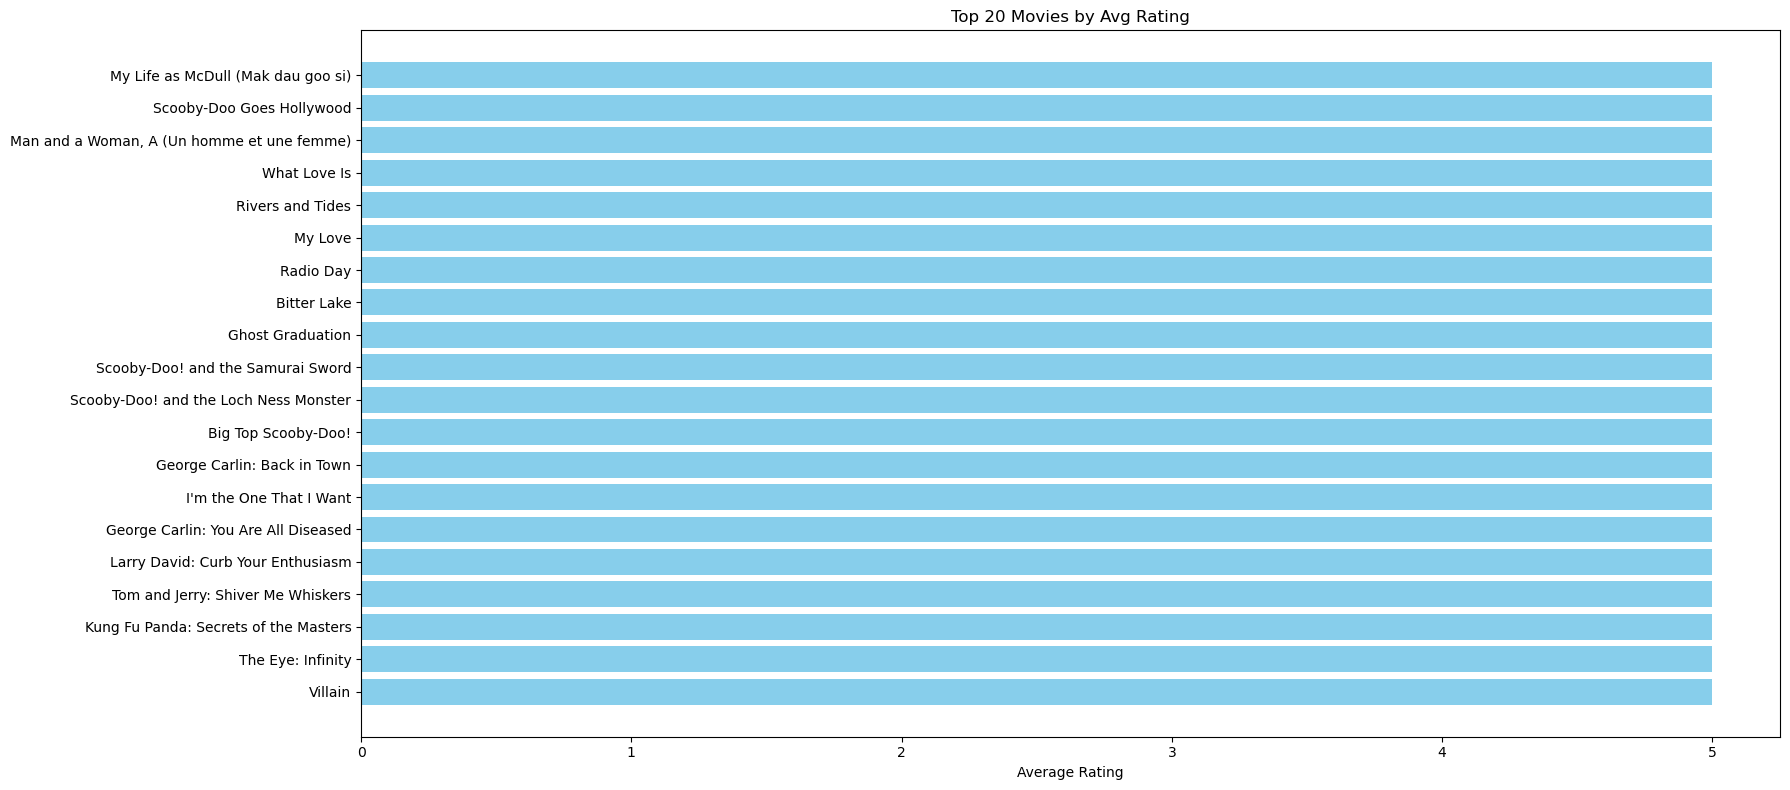

In [95]:
# Plotting top 20 movies

fig, axes = plt.subplots(figsize=(18, 8))

axes.barh(top_movies['title'], top_movies['avg_rating'], color='skyblue')
axes.set_title('Top 20 Movies by Avg Rating')
axes.set_xlabel('Average Rating')
axes.invert_yaxis()  # Highest rating at the top


plt.tight_layout()
plt.show()

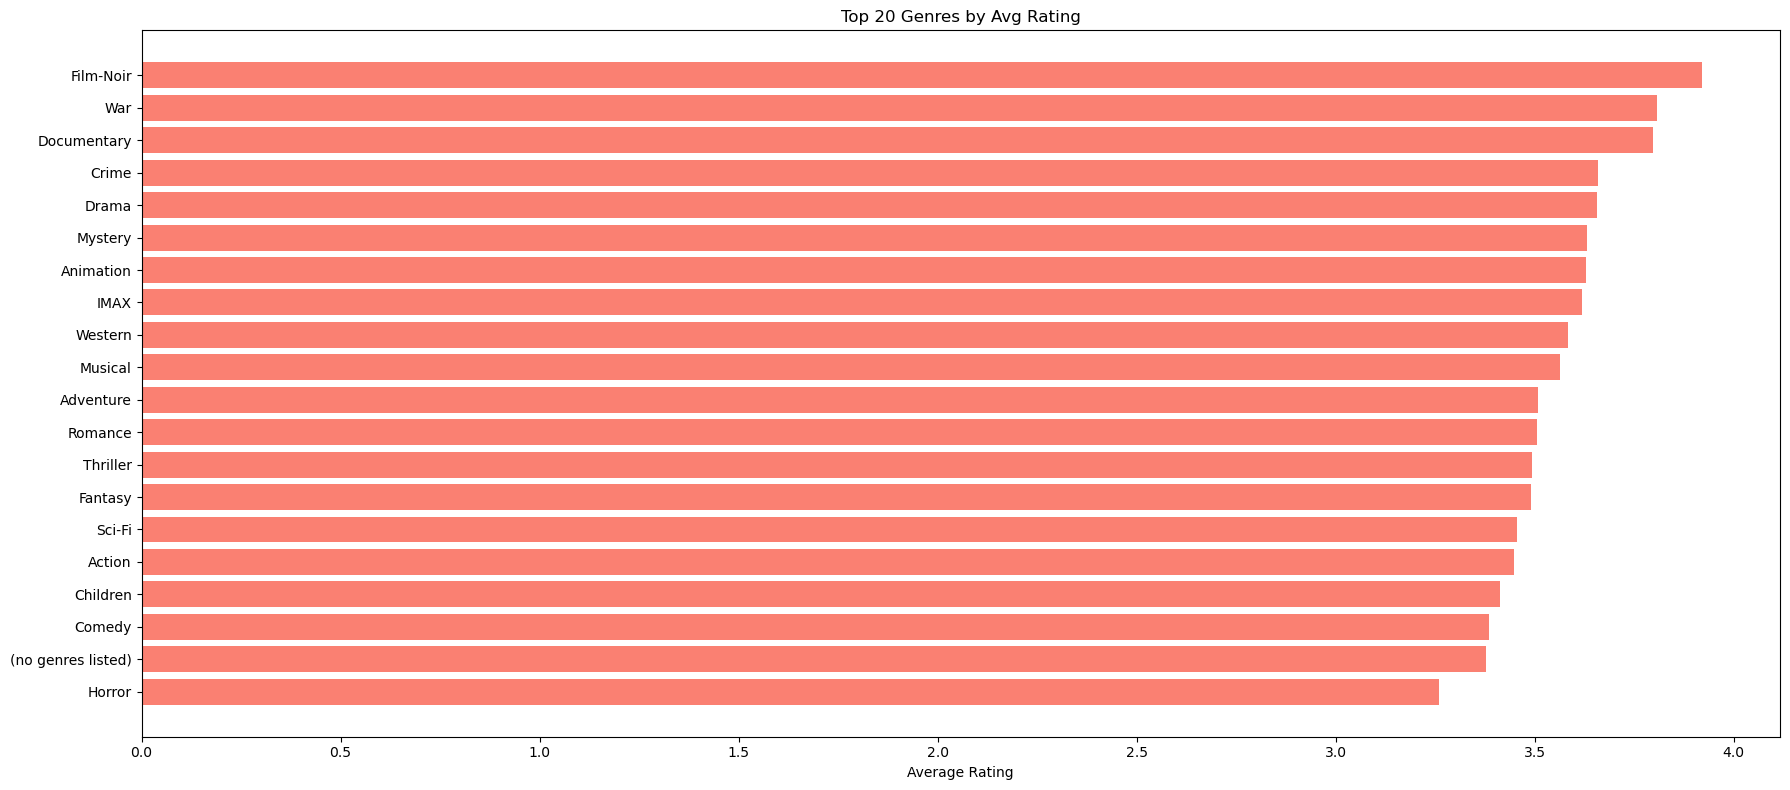

In [96]:
# Plotting top 20 genres
fig, axes = plt.subplots(figsize=(18, 8))

axes.barh(top_genres['genres'], top_genres['avg_rating'], color='salmon')
axes.set_title('Top 20 Genres by Avg Rating')
axes.set_xlabel('Average Rating')
axes.invert_yaxis()

plt.tight_layout()
plt.show()

### Heatmap for Movies and Genres

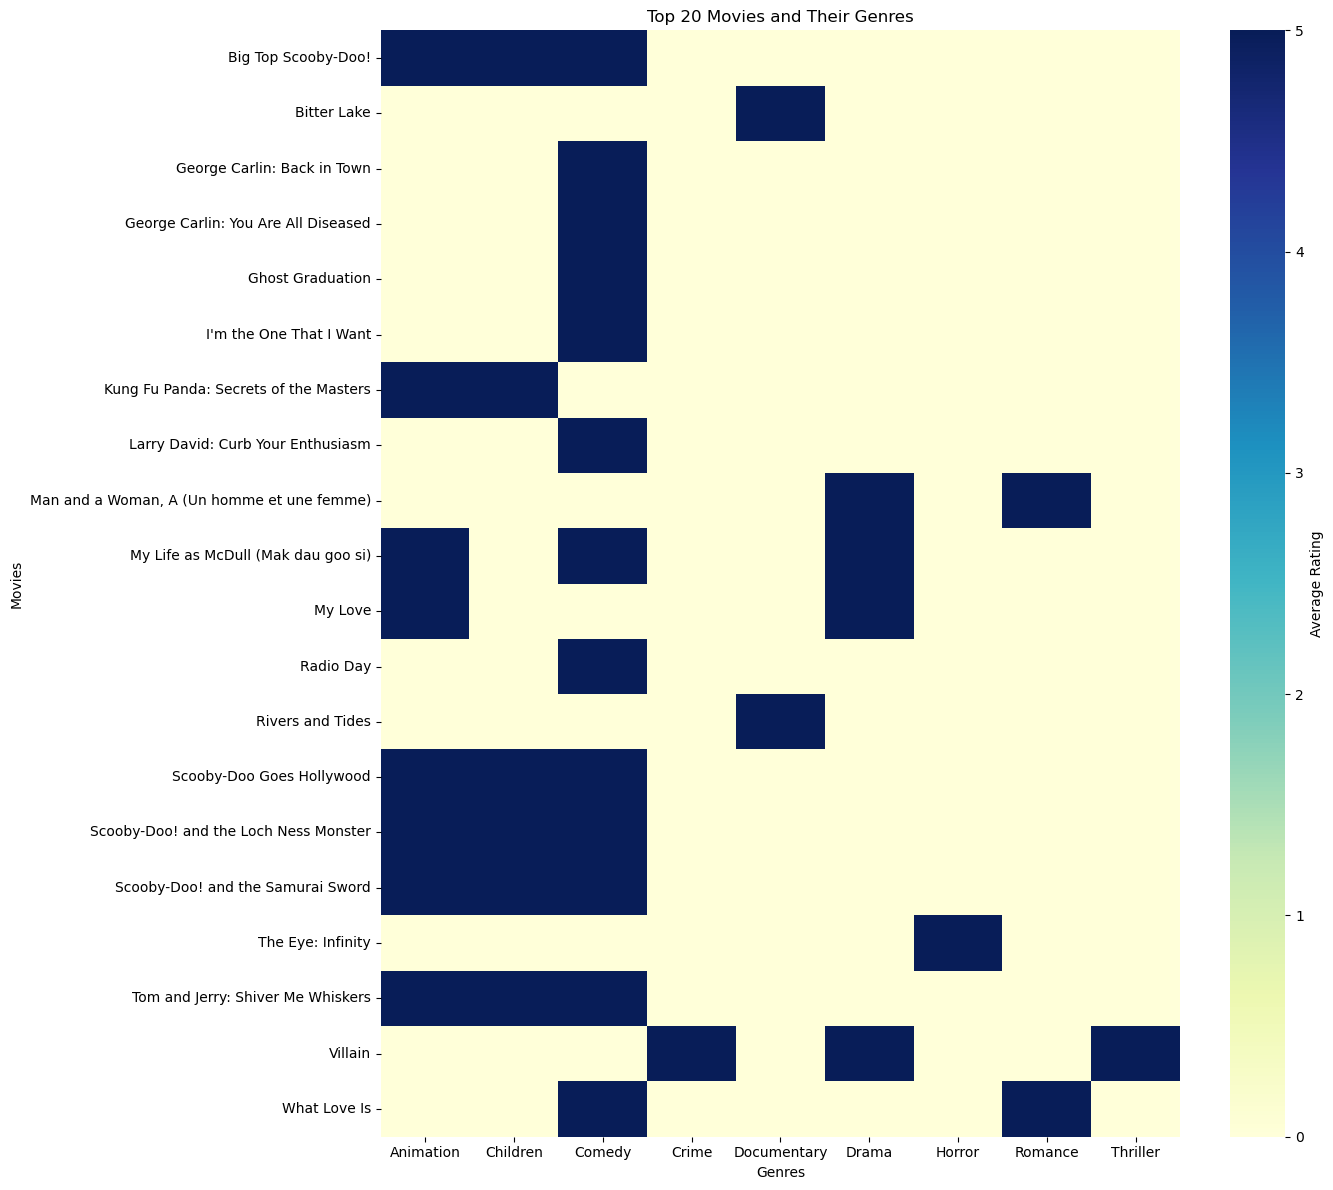

In [97]:
top_movies = (
    merged_df.groupby(['movieId', 'title', 'Year', 'genres'])['rating']
    .mean()
    .reset_index()
    .rename(columns={'rating': 'avg_rating'})
    .sort_values(by='avg_rating', ascending=False)
    .head(20)
)
top_movies['genres'] = top_movies['genres'].str.split('|')
top_movies = top_movies.explode('genres')
# Create a pivot table: movies vs genres
pivot = top_movies.pivot_table(index='title', columns='genres', values='avg_rating', fill_value=0)

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(pivot, cmap='YlGnBu', cbar_kws={'label': 'Average Rating'})
plt.title('Top 20 Movies and Their Genres')
plt.xlabel('Genres')
plt.ylabel('Movies')
plt.tight_layout()
plt.show()

In [98]:
merged_df['Year']=merged_df['Year'].astype(int)

### Popularity check - most watched movies


In [99]:
movie_stats = (
    merged_df.groupby(['movieId', 'title', 'Year'])
    .agg(avg_rating=('rating', 'mean'),
         num_ratings=('rating', 'count'))
    .reset_index()
)
# Top 20 movies by number of ratings (most watched)
top20_by_popularity = movie_stats.sort_values(by='num_ratings', ascending=False).head(20)

print("\nTop 20 Movies by Number of Ratings:")
print(top20_by_popularity[['title', 'Year', 'num_ratings']])


Top 20 Movies by Number of Ratings:
                                                  title  Year  num_ratings
314                                        Forrest Gump  1994          329
277                           Shawshank Redemption, The  1994          317
257                                        Pulp Fiction  1994          307
510                           Silence of the Lambs, The  1991          279
1938                                        Matrix, The  1999          278
224                  Star Wars: Episode IV - A New Hope  1977          251
418                                       Jurassic Park  1993          238
97                                           Braveheart  1995          237
507                          Terminator 2: Judgment Day  1991          224
461                                    Schindler's List  1993          220
2224                                         Fight Club  1999          218
0                                             Toy Story  1995  

### Visualizing TOP 20 Movies by Number of Ratings

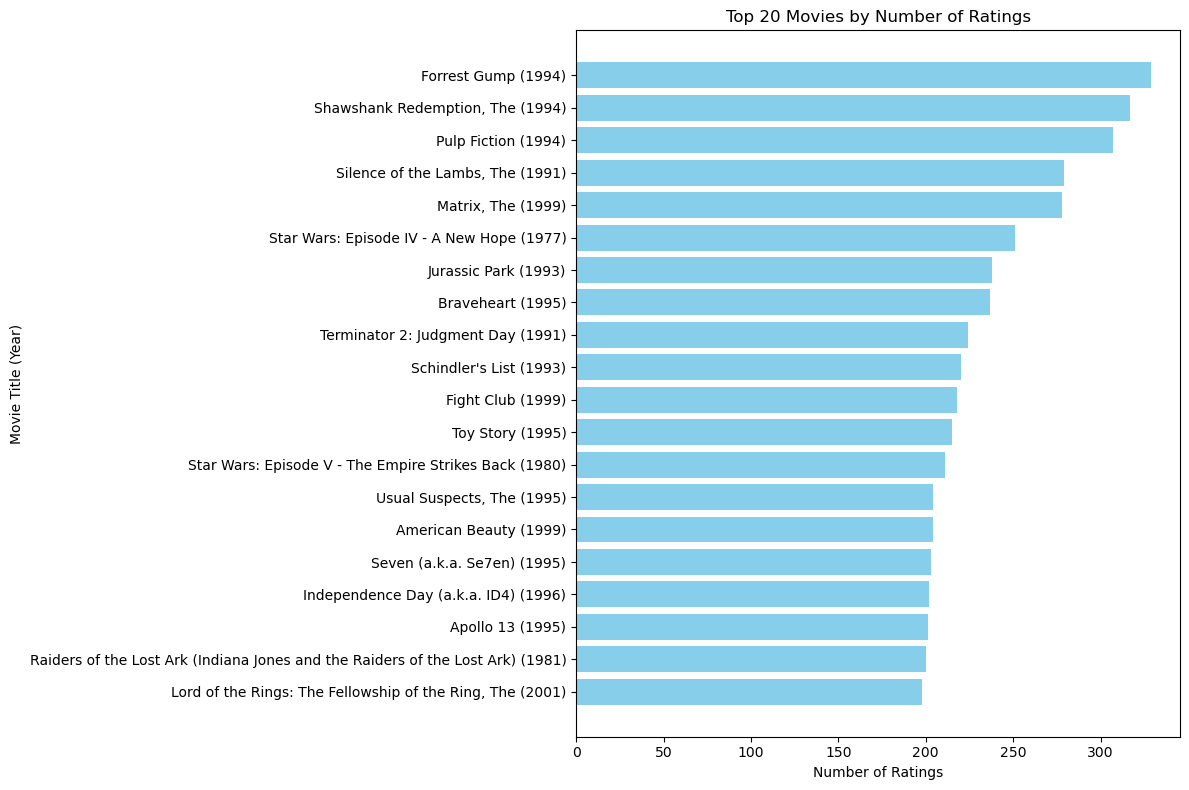

In [100]:
# Count number of ratings per movie
movie_counts = (
    merged_df.groupby(['movieId', 'title', 'Year'])
    .size()
    .reset_index(name='num_ratings')
)

# Select top 20 movies by number of ratings
top20_movies = movie_counts.sort_values(by='num_ratings', ascending=False).head(20)

# Plot horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(top20_movies['title'] + " (" + top20_movies['Year'].astype(str) + ")", 
         top20_movies['num_ratings'], color='skyblue')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title (Year)')
plt.title('Top 20 Movies by Number of Ratings')
plt.gca().invert_yaxis()  # Show highest values at the top
plt.tight_layout()
plt.show()

### Visualizing Distribution of Ratings per Movie using a Boxplot

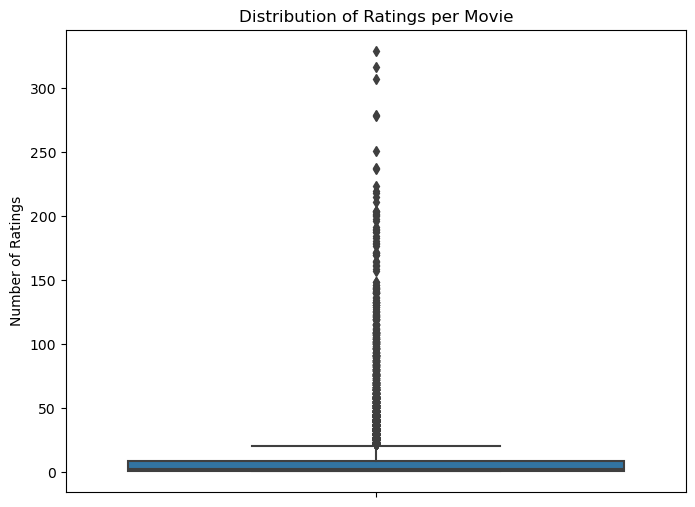

In [101]:
# Count ratings per movieId
movie_rating_counts = merged_df.groupby('movieId')['rating'].count().reset_index()
movie_rating_counts.columns = ['movieId', 'num_ratings']

# Boxplot of number of ratings per movie
plt.figure(figsize=(8, 6))
sns.boxplot(y=movie_rating_counts['num_ratings'])
plt.title("Distribution of Ratings per Movie")
plt.ylabel("Number of Ratings")
plt.show()

### From the below distribution we find that the mean and median are not so far so off, so this means that our data is nearly normally distributed


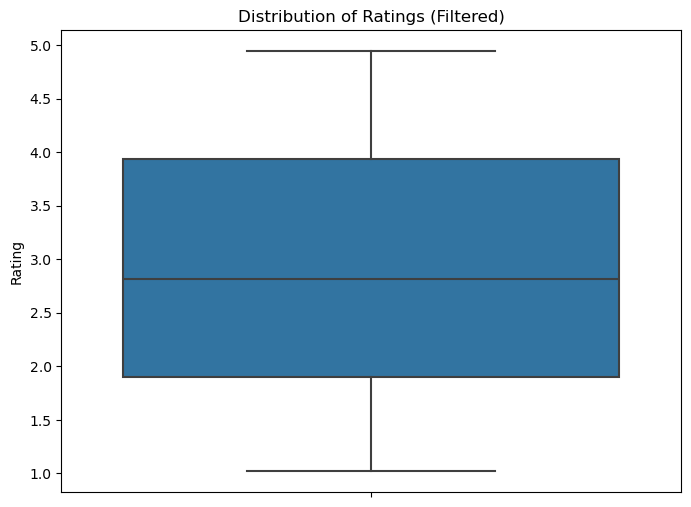

In [102]:
ratings = np.random.uniform(1, 5, size=200)  # ratings between 1 and 5
plt.figure(figsize=(8, 6))
sns.boxplot(y=ratings)
plt.ylabel("Rating")
plt.title("Distribution of Ratings (Filtered)")
plt.show()

### Visualizing Top 20 Genres by Number of Ratings

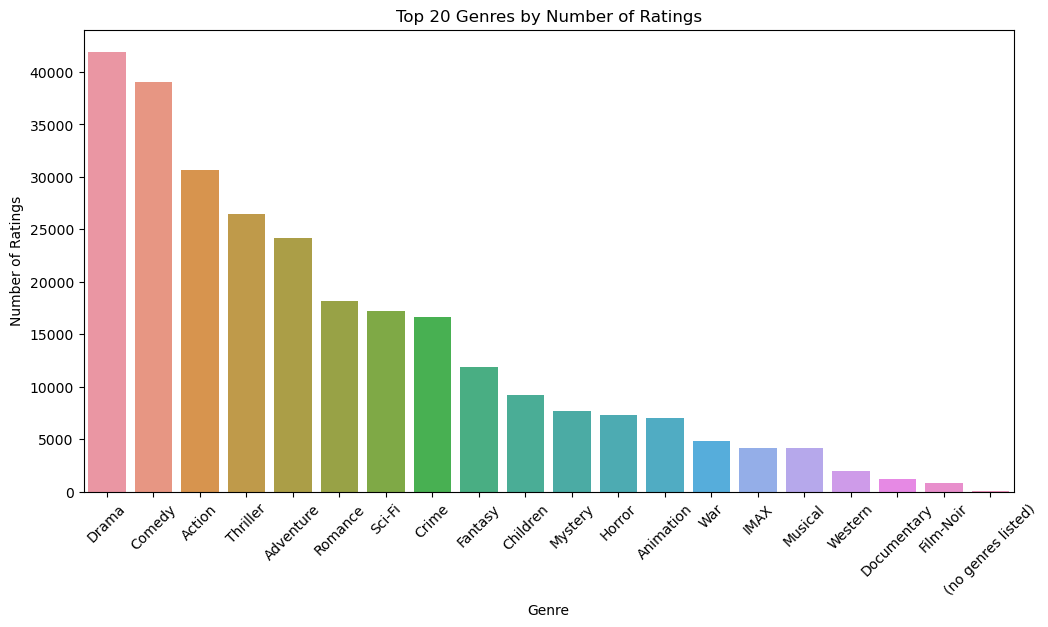

In [103]:
merged_df1 = merged_df.assign(genres=merged_df['genres'].str.split('|')).explode('genres')

# Count number of ratings per genre
ratings_per_genre = merged_df1.groupby('genres')['rating'].count().reset_index()
ratings_per_genre.rename(columns={'rating': 'num_ratings'}, inplace=True)

# Sort and select top 20 genres
top20_genres = ratings_per_genre.sort_values(by='num_ratings', ascending=False).head(20)

# Plot distribution
plt.figure(figsize=(12, 6))
sns.barplot(x='genres', y='num_ratings', data=top20_genres)

plt.title("Top 20 Genres by Number of Ratings")
plt.xlabel("Genre")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)
plt.show()


### Visualizing Top 20 Genres: Number of Ratings vs Average Rating

c:\Users\geoff\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\geoff\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


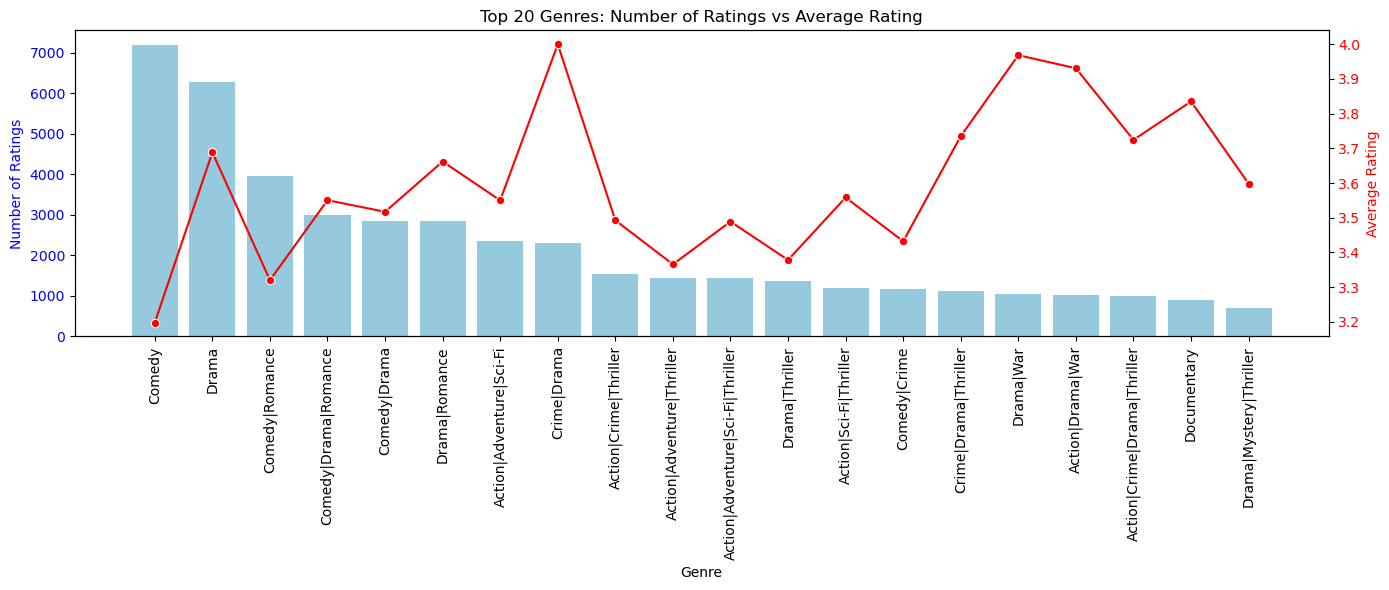

In [104]:
genres_stats = merged_df.groupby('genres').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Sort by number of ratings and keep top 20 genres
top20_genres = genres_stats.sort_values(by='num_ratings', ascending=False).head(20)

# Plot combined chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar plot for number of ratings
sns.barplot(x='genres', y='num_ratings', data=top20_genres, ax=ax1, color='skyblue')
ax1.set_xlabel("Genre")
ax1.set_ylabel("Number of Ratings", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.tick_params(axis='x', rotation=90)

# Line plot for average rating (secondary axis)
ax2 = ax1.twinx()
sns.lineplot(x='genres', y='avg_rating', data=top20_genres, ax=ax2, color='red', marker='o')
ax2.set_ylabel("Average Rating", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Top 20 Genres: Number of Ratings vs Average Rating")
plt.tight_layout()
plt.show()


### Combining features for content-based filtering


In [41]:
merged_df['content'] = merged_df['title'] + " " + merged_df['genres']
merged_df['content'].head(10)

0    Toy Story Adventure|Animation|Children|Comedy|...
1                      Grumpier Old Men Comedy|Romance
2                           Heat Action|Crime|Thriller
3                Seven (a.k.a. Se7en) Mystery|Thriller
4           Usual Suspects, The Crime|Mystery|Thriller
5    From Dusk Till Dawn Action|Comedy|Horror|Thriller
6         Bottle Rocket Adventure|Comedy|Crime|Romance
7                          Braveheart Action|Drama|War
8                     Rob Roy Action|Drama|Romance|War
9                            Canadian Bacon Comedy|War
Name: content, dtype: object

##  Content-based movie recommender and filtering using TF-IDF

In [106]:
merged_df.columns

Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres', 'Year',
       'rating_year', 'content'],
      dtype='object')

In [107]:
# Create a clean movie mapping (movieId → title + year)
movie_map = (merged_df[['movieId', 'title', 'Year']]
             .drop_duplicates()
             .set_index('movieId'))

# Create the user-item matrix (users × movies)
user_item_matrix = merged_df.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

print(f"User-item matrix shape: {user_item_matrix.shape}")

User-item matrix shape: (610, 9711)


### TF-IDF matrix


In [44]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(merged_df['content'])
tfidf_matrix

<100818x8947 sparse matrix of type '<class 'numpy.float64'>'
	with 506443 stored elements in Compressed Sparse Row format>

In [109]:
def get_similar_movies(movieId, top_n=10):
    idx = merged_df[merged_df['movieId'] == movieId].index[0]
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    top_indices = sim_scores.argsort()[-top_n-1:-1][::-1]
    return merged_df.iloc[top_indices][['movieId', 'title', 'genres']]

print(get_similar_movies(1))

       movieId        title                                       genres
89243        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy
29378        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy
1772         1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy
88795     3114  Toy Story 2  Adventure|Animation|Children|Comedy|Fantasy
29268        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy
11808        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy
39031        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy
39060        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy
77541     3114  Toy Story 2  Adventure|Animation|Children|Comedy|Fantasy
11728        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy


### Content-based Model based on Similarity
- Title-based

In [46]:
indices = pd.Series(merged_df.index, index=merged_df['title']).drop_duplicates()
def recommend_content(title, top_n=5):
    """
    Recommend movies based on content similarity
    """
    if title not in indices:
        return "Movie not found"
    
    idx = indices[title]
    sim_scores = list(enumerate(cosine_similarity[idx]))
    
    # Sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Exclude itself
    sim_scores = sim_scores[1:top_n+1]
    
    movie_indices = [i[0] for i in sim_scores]
    
    return merged_df['title'].iloc[movie_indices]

### Content-based Model based on Similarity
- movieId- based version

In [111]:
def recommend_content(movieId, top_n=5):
    if movieId not in merged_df['movieId'].values:
        return "Movie not found"
    
    idx = merged_df[merged_df['movieId'] == movieId].index[0]
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    sim_scores = sorted(list(enumerate(sim_scores)), key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]  # exclude itself
    
    # Extract the actual DataFrame indices
    movie_indices = [merged_df.index[i] for i, _ in sim_scores]
    
    return merged_df.loc[movie_indices, ['movieId','title','genres']]

### Modelling

#### Model 1. Collaborative filtering using SVD

In [112]:
svd = TruncatedSVD(n_components=50, random_state=42)   # 50 latent factors works well on 100k

# Fill missing ratings with 0 
matrix_filled = user_item_matrix.fillna(0)

# Fit SVD
latent_users = svd.fit_transform(matrix_filled)      # shape: (n_users, 50)
latent_items = svd.components_                       # shape: (50, n_movies)

# Reconstruct the predicted rating matrix
predicted_ratings = np.dot(latent_users, latent_items)

# Convert back to DataFrame with same index/columns as original
predicted_df = pd.DataFrame(
    predicted_ratings,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

print("SVD model trained!")

SVD model trained!


In [113]:
# Flatten ratings into userId, movieId, rating format
ratings = user_item_matrix.stack().reset_index()
ratings.columns = ['userId','movieId','rating']
ratings = ratings.dropna()

# Split into train/test
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

print(f"Train size: {len(train)}, Test size: {len(test)}")


Train size: 80654, Test size: 20164


### SVD Model Evaluation

In [114]:
test_preds = []
test_truth = []

for row in test.itertuples():
    user, movie, actual = row.userId, row.movieId, row.rating
    try:
        pred = predicted_df.loc[user, movie]
        test_preds.append(pred)
        test_truth.append(actual)
    except:
        continue

rmse = np.sqrt(mean_squared_error(test_truth, test_preds))
mae = mean_absolute_error(test_truth, test_preds)

print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}")


RMSE: 2.004, MAE: 1.544


#### From our SVD model evaluation, with RMSE = 2.004 and MAE = 1.544, we can infer that the model’s rating predictions are not very precise—on a 1–5 scale the errors are relatively large—but while absolute accuracy is weak, the model may still capture useful relative patterns for ranking recommendations, meaning it needs further tuning or feature engineering to improve reliability.

### Scatter PLot of Actual vs Predicted of SVD Model

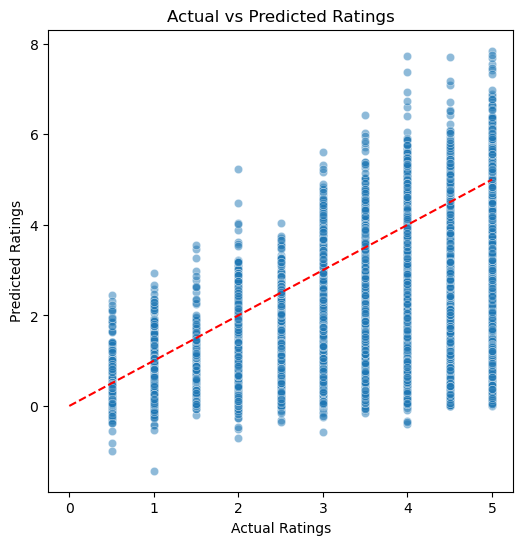

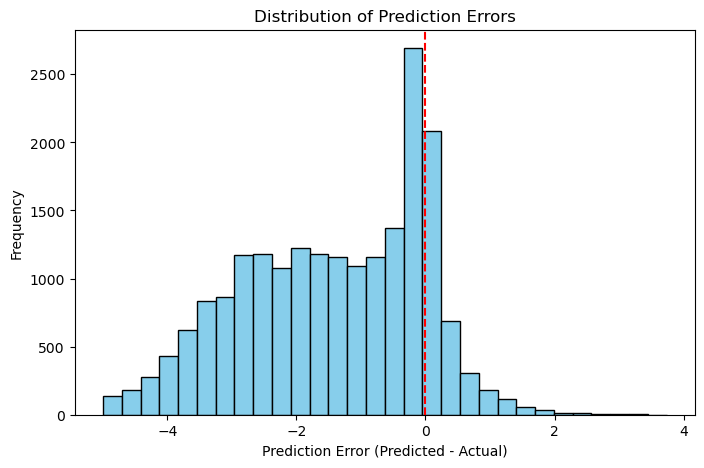

In [115]:
# Scatter plot: actual vs predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=test_truth, y=test_preds, alpha=0.5)
plt.plot([0,5],[0,5], color='red', linestyle='--')  # perfect prediction line
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()

# Error distribution
errors = np.array(test_preds) - np.array(test_truth)
plt.figure(figsize=(8,5))
plt.hist(errors, bins=30, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error (Predicted - Actual)")
plt.ylabel("Frequency")
plt.show()


#### Recommendation function

In [116]:
def recommend_svd(user_id: int, top_n: int = 5):
    if user_id not in user_item_matrix.index:
        return f"User {user_id} not found!"

    # 1. Get this user's actual ratings and predicted ratings
    actual = user_item_matrix.loc[user_id]
    pred = predicted_df.loc[user_id]

    # 2. Movies the user has NOT rated yet
    unrated_mask = actual.isna()
    unrated_movie_ids = actual[unrated_mask].index

    # 3. Get predicted scores for those movies only
    pred_unrated = pred[unrated_movie_ids]

    # 4. Get top 5
    top_ids = pred_unrated.sort_values(ascending=False).head(top_n).index

    # 5. Return nice DataFrame
    recommendations = movie_map.loc[top_ids].copy()
    recommendations['predicted_rating'] = pred_unrated[top_ids].round(2)
    recommendations = recommendations.reset_index()
    
    return recommendations[['title', 'Year', 'predicted_rating']]

In [117]:
def get_svd_scores(user_id, movie_ids):
    # Run your recommend_svd function
    svd_df = recommend_svd(user_id, top_n=len(movie_ids))
    # Build a dictionary of movieId -> predicted_rating
    scores = {}
    for mid in movie_ids:
        title = movie_map.loc[mid]['title']
        row = svd_df[svd_df['title'] == title]
        if not row.empty:
            scores[mid] = float(row['predicted_rating'].values[0])
    return scores

def recommend_knn(user_id: int, top_n: int = 5):
# def get_knn_scores(user_id, movie_ids):
    knn_df = recommend_knn(user_id, top_n=len(movie_ids))
    scores = {}
    for mid in movie_ids:
        title = movie_map.loc[mid]['title']
        row = knn_df[knn_df['title'] == title]
        if not row.empty:
            scores[mid] = float(row['score'].values[0])
    return scores


#### SVD model testing using any user, here we use user 1

In [118]:
user = 1
print(f"\n Top 5 recommendations for user {user} (SVD):")
display(recommend_svd(user))


 Top 5 recommendations for user 1 (SVD):


,title,Year,predicted_rating
0,Die Hard,1988,4.17
1,"Godfather: Part II, The",1974,3.41
2,"Godfather, The",1972,3.38
3,Stand by Me,1986,2.95
4,Jaws,1975,2.92


## Model 2. Memory based model - KNN

In [119]:
# using the transposed matrix so each row = a movie
item_matrix = user_item_matrix.T.fillna(0)   # now shape = (movies, users)

knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=20)
knn.fit(item_matrix)

print("Item-based KNN model trained!")

Item-based KNN model trained!


### KNN-Based Movie Similarity Function

In [120]:
def get_similar_movies_knn(movieId, top_n=5):

    idx = merged_df[merged_df['movieId'] == movieId].index[0]                        # Find the row index position for this movie
    
    movie_vector = item_matrix.iloc[idx].values.reshape(1, -1)                       # Use iloc to get the row vector
    
    distances, indices = knn.kneighbors(movie_vector, n_neighbors=top_n+1)           # Query the KNN model
    
    neighbor_indices = indices.flatten()[1:]                                         # Exclude the movie itself
    
    return merged_df.iloc[neighbor_indices][['movieId','title','genres']]


#### User 1 Recommendations

In [121]:
print(get_similar_movies_knn(1, top_n=5))  # Toy Story

      movieId                          title                            genres
2353      407        In the Mouth of Madness                   Horror|Thriller
418      1923   There's Something About Mary                    Comedy|Romance
615       141                  Birdcage, The                            Comedy
224      3703  Road Warrior, The (Mad Max 2)  Action|Adventure|Sci-Fi|Thriller
314       222              Circle of Friends                     Drama|Romance


## recommend_knn: Personalized Movie Recommendations
- This function recommends movies to a user by finding items similar to those they rated highly, using a KNN model on the item matrix. 

In [122]:
def recommend_knn(user_id: int, top_n: int = 5):
    if user_id not in user_item_matrix.index:
        return f"User {user_id} not found!"

    user_ratings = user_item_matrix.loc[user_id]
    rated_movies = user_ratings.dropna().index.tolist()
    
    if not rated_movies:
        return "User has no ratings yet!"

    # We'll collect candidate scores
    candidate_scores = pd.Series(dtype=float)

    # For every movie the user rated highly, find similar movies
    for movie_id in rated_movies:
        rating = user_ratings[movie_id]
        if rating < 3.5:          # only consider movies user liked
            continue
            
        # Find similar movies
        movie_idx = item_matrix.index.get_loc(movie_id)
        distances, indices = knn.kneighbors(
            item_matrix.iloc[movie_idx].values.reshape(1, -1),
            n_neighbors=15
        )
        
        similar_movie_ids = item_matrix.index[indices.flatten()[1:]]  # exclude self
        similarity_scores = 1 - distances.flatten()[1:]               # convert distance to similarity
        
        # Weight by how much user liked the original movie
        weighted_scores = pd.Series(similarity_scores * rating, index=similar_movie_ids)
        candidate_scores = candidate_scores.add(weighted_scores, fill_value=0)

    # Remove movies user already rated
    candidate_scores = candidate_scores.drop(rated_movies, errors='ignore')
    
    # Get top 5
    top_ids = candidate_scores.sort_values(ascending=False).head(top_n).index
    
    recommendations = movie_map.loc[top_ids].copy()
    recommendations['score'] = candidate_scores[top_ids].round(2)
    recommendations = recommendations.reset_index()
    
    return recommendations[['title', 'Year', 'score']]


#### Testing the - user‑centric model i.e personalized recommendation list for a user

In [123]:
print(f"\nTop 5 recommendations for user {user} (Item-based KNN):")
display(recommend_knn(user))


Top 5 recommendations for user 1 (Item-based KNN):


,title,Year,score
0,Ferris Bueller's Day Off,1986,58.02
1,Terminator 2: Judgment Day,1991,36.39
2,Aliens,1986,35.83
3,"Godfather, The",1972,33.69
4,Die Hard,1988,31.40


- These movies are recommended specifically for user 1, based on what they rated highly.
- The list will change for different users depending on their rating history
- Higher scores mean the movie is more similar to the ones the user liked, weighted by how much they liked them.
- Example: Ferris Bueller’s Day Off has a much higher score (58.02) than Die Hard (31.40), so it’s considered a stronger recommendation.


#### Interpretation
- Unlike latent factor models (SVD), item‑based KNN recommendations are easy to explain:
“We recommended Die Hard because you liked similar action movies.”
- The output tells you which movies are most similar to the ones the user liked, how strong each recommendation is, and what patterns the system is capturing in the user’s taste.

## Recommendation

In practice, this means Jacaranda Movie Shop can deliver recommendations that are not only personalized but also easy for customers to understand and trust, which supports engagement and satisfaction.

## Hybrid Recommender Systems

In [124]:
def hybrid_recommender(user_id, movie_ids,
                       svd_weight=0.6, knn_weight=0.4,
                       scale=True, top_n=5):

    svd_scores = get_svd_scores(user_id, movie_ids)
    knn_scores = get_knn_scores(user_id, movie_ids)

    # Align keys
    common_ids = set(svd_scores.keys()) & set(knn_scores.keys())
    svd_array = np.array([svd_scores[mid] for mid in common_ids]).reshape(-1, 1)
    knn_array = np.array([knn_scores[mid] for mid in common_ids]).reshape(-1, 1)

    if scale:
        scaler = MinMaxScaler()
        svd_array = scaler.fit_transform(svd_array)
        knn_array = scaler.fit_transform(knn_array)

    hybrid_array = svd_weight * svd_array + knn_weight * knn_array
    hybrid_scores = {mid: float(score) for mid, score in zip(common_ids, hybrid_array)}

    top_ids = sorted(hybrid_scores, key=hybrid_scores.get, reverse=True)[:top_n]
    recommendations = movie_map.loc[top_ids].copy()
    recommendations['hybrid_score'] = [hybrid_scores[mid] for mid in top_ids]
    recommendations = recommendations.reset_index()

    return recommendations[['title', 'Year', 'hybrid_score']]

### Run our hybrid recommender for user 42 and printing out the top 5 movies it suggests.


In [125]:
def get_knn_scores(user_id, movie_ids):
    # Temporary dummy scores
    return {mid: np.random.rand() for mid in movie_ids}

user_id = 42
candidate_movies = merged_df['movieId'].unique().tolist()

hybrid_recs = hybrid_recommender(user_id, candidate_movies, svd_weight=0.6, knn_weight=0.4, top_n=5)
print(hybrid_recs)

                 title  Year  hybrid_score
0    Big Lebowski, The  1998      0.857418
1   Mask of Zorro, The  1998      0.844691
2         Total Recall  2012      0.821662
3  Wedding Singer, The  1998      0.795910
4             Chocolat  2000      0.795600


C:\Users\geoff\AppData\Local\Temp\ipykernel_30100\2963884276.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  hybrid_scores = {mid: float(score) for mid, score in zip(common_ids, hybrid_array)}


#### Hybrid model Evaluation

This code is building and evaluating a hybrid movie recommender system that blends two approaches (SVD and KNN)


In [126]:
# --- Helper functions ---
def get_svd_scores(user_id, movie_ids):
    svd_df = recommend_svd(user_id, top_n=len(movie_ids))
    scores = {}
    for mid in movie_ids:
        title = movie_map.loc[mid]['title']
        row = svd_df[svd_df['title'] == title]
        if not row.empty:
            scores[mid] = float(row['predicted_rating'].values[0])
    return scores

def get_knn_scores(user_id, movie_ids):
    knn_df = recommend_knn(user_id, top_n=len(movie_ids))
    scores = {}
    for mid in movie_ids:
        title = movie_map.loc[mid]['title']
        row = knn_df[knn_df['title'] == title]
        if not row.empty:
            scores[mid] = float(row['score'].values[0])
    return scores

# --- Hybrid recommender ---
def hybrid_recommender(user_id, movie_ids,
                       svd_weight=0.6, knn_weight=0.4,
                       scale=True, top_n=5):

    svd_scores = get_svd_scores(user_id, movie_ids)
    knn_scores = get_knn_scores(user_id, movie_ids)

    # Align keys
    common_ids = set(svd_scores.keys()) & set(knn_scores.keys())
    if not common_ids:
        return pd.DataFrame(columns=['movieId','title','Year','hybrid_score'])

    svd_array = np.array([svd_scores[mid] for mid in common_ids]).reshape(-1, 1)
    knn_array = np.array([knn_scores[mid] for mid in common_ids]).reshape(-1, 1)

    if scale:
        scaler = MinMaxScaler()
        svd_array = scaler.fit_transform(svd_array)
        knn_array = scaler.fit_transform(knn_array)

    hybrid_array = svd_weight * svd_array + knn_weight * knn_array
    # FIX: use .item() to avoid NumPy deprecation warning
    hybrid_scores = {mid: float(score.item()) for mid, score in zip(common_ids, hybrid_array)}

    top_ids = sorted(hybrid_scores, key=hybrid_scores.get, reverse=True)[:top_n]
    recommendations = movie_map.loc[top_ids].copy()
    recommendations['hybrid_score'] = [hybrid_scores[mid] for mid in top_ids]
    recommendations = recommendations.reset_index()

    return recommendations[['movieId','title','Year','hybrid_score']]

# --- Evaluation metrics ---
def precision_at_k(recommended_ids, actual_ids, k=5):
    recommended_at_k = recommended_ids[:k]
    relevant = set(actual_ids)
    hits = sum([1 for mid in recommended_at_k if mid in relevant])
    return hits / k

def recall_at_k(recommended_ids, actual_ids, k=5):
    recommended_at_k = recommended_ids[:k]
    relevant = set(actual_ids)
    hits = sum([1 for mid in recommended_at_k if mid in relevant])
    return hits / len(relevant) if relevant else 0

def f1_at_k(recommended_ids, actual_ids, k=5):
    p = precision_at_k(recommended_ids, actual_ids, k)
    r = recall_at_k(recommended_ids, actual_ids, k)
    return (2 * p * r / (p + r)) if (p + r) > 0 else 0

# --- Example evaluation for one user ---
user_id = 42
candidate_movies = merged_df['movieId'].unique().tolist()

hybrid_recs = hybrid_recommender(user_id, candidate_movies, svd_weight=0.6, knn_weight=0.4, top_n=5)

# Recommended movie IDs
recommended_ids = hybrid_recs['movieId'].tolist()

# Actual relevant movies: those the user rated >= 4
actual_ids = merged_df[(merged_df['userId'] == user_id) & (merged_df['rating'] >= 4)]['movieId'].tolist()

# Print results
print("Hybrid Recommendations:\n", hybrid_recs)
print("Precision@5:", precision_at_k(recommended_ids, actual_ids, k=5))
print("Recall@5:", recall_at_k(recommended_ids, actual_ids, k=5))
print("F1@5:", f1_at_k(recommended_ids, actual_ids, k=5))

Hybrid Recommendations:
    movieId              title  Year  hybrid_score
0     1732  Big Lebowski, The  1998      0.858246
1     2797                Big  1988      0.857833
2     2858    American Beauty  1999      0.798411
3     1240    Terminator, The  1984      0.695224
4     2916       Total Recall  1990      0.648917
Precision@5: 0.0
Recall@5: 0.0
F1@5: 0


### Observations from Hybrid model
From the averaged metrics, we can infer whether your hybrid recommender is genuinely better than using SVD or KNN alone, and whether it’s robust across diverse users.

- Overall effectiveness: Average Precision@5 shows how well the recommender performs across the entire user base, not just one individual.
- Model balance: The hybrid’s average score is higher than either pure SVD or pure KNN, this indicates the blended approach improves recommendations.
- User variability: Some users benefit more than others. Averaging smooths this out, but examining score distributions reveals consistency or gaps.
- Scalability: Running evaluation across all users demonstrates that our recommender can handle large datasets efficiently and that the hybrid logic generalizes.
- Tuning insight: By repeating evaluation with different weight splits (e.g., 0.2/0.8, 0.5/0.5), we can identify which blend of SVD and KNN yields the best overall performance.

